### Kipf-Welling implementation (Full batch)

In [1]:
# imports
import sys
from pathlib import Path

sys.path.append(str(Path("..").resolve()))

from src.utils import *
from src.model import *
from src.train import *
from typing import Any
from dataclasses import dataclass
from sklearn.manifold import TSNE

import torch
import torch.optim as optim
import matplotlib.pyplot as plt
import argparse
import math
import time
import numpy as np

/local/data/ipv577/projects_new/.project_venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


2.8.0+cu128
12.8


In [6]:
print(torch.__version__)
print(torch.version.cuda)
print(torch.cuda.is_available())

2.8.0+cu128
12.8
True


In [2]:
def summarize_results(results, dataset_name):
    runs = results["run_summaries"]

    test_accs = [r["test_acc"] for r in runs]
        
    short_results = {
        "dataset": dataset_name,
        "test_acc_mean": np.mean(test_accs),
        "test_acc_std": np.std(test_accs, ddof=1),
        "best_val_acc_mean": np.mean([r["best_val_acc"] for r in runs]),
        "best_val_loss_mean": np.mean([r["best_val_loss"] for r in runs]),
        "total_train_time_mean": np.mean([r["total_train_time"] for r in runs]),
        "mean_epoch_train_time_mean": np.mean([r["mean_epoch_train_time"] for r in runs]),
    }
    return short_results

In [3]:
# run experiments for all 3 data sets; each for 9 iterations

cfg_paths = [
    "../configs/default_config.yaml",
    "../configs/pubmed.yaml",
    "../configs/citeseer.yaml",
]

summaries = []

for path in cfg_paths:
    cfg = load_config(path)
    results = run_from_cfg(cfg)
    dataset_name = cfg["data"]["data_name"]
    summaries.append(summarize_results(results, dataset_name))

Dataset Cora already available, no download necessary.
device: cuda
HYPERPARAMS lr: 0.01 epochs: 200 weight-decay: 0.0005
MODEL ARCHITECTURE: input_dim: 1433 hidden_dim: 16 output_dim: 7 dropout: 0.5
------------- DATA SET INFOS ------------- 
Number of nodes: 2708
Number of edges: 10556
Number of features per Node: 1433
Number of targets in this dataset: 7
Epoch: 1 | Train Loss: 1.9485 | Val Loss: 1.8686 | Val Acc: 0.6080 | Train Time: 0.1399s
Epoch: 2 | Train Loss: 1.8311 | Val Loss: 1.7770 | Val Acc: 0.7300 | Train Time: 0.0027s
Epoch: 3 | Train Loss: 1.7027 | Val Loss: 1.6724 | Val Acc: 0.7500 | Train Time: 0.0012s
Epoch: 4 | Train Loss: 1.5519 | Val Loss: 1.5733 | Val Acc: 0.7640 | Train Time: 0.0011s
Epoch: 5 | Train Loss: 1.4168 | Val Loss: 1.4819 | Val Acc: 0.7700 | Train Time: 0.0011s
Epoch: 6 | Train Loss: 1.2716 | Val Loss: 1.4017 | Val Acc: 0.7680 | Train Time: 0.0011s
Epoch: 7 | Train Loss: 1.1455 | Val Loss: 1.3277 | Val Acc: 0.7660 | Train Time: 0.0011s
Epoch: 8 | Train 

In [6]:
# plotting functions
import json
import numpy as np
import matplotlib.pyplot as plt

def load_results(path):
    with open(path, "r") as f:
        return json.load(f)

def pad_and_stats(curves):
    max_len = max(len(c) for c in curves)
    arr = np.full((len(curves), max_len), np.nan)
    for i, c in enumerate(curves):
        arr[i, :len(c)] = c
    mean = np.nanmean(arr, axis=0)
    std = np.nanstd(arr, axis=0, ddof=1)
    epochs = np.arange(1, max_len + 1)
    return epochs, mean, std

def plot_dataset_results(path, dataset_name):
    results = load_results(path)

    histories = results["all_histories"]
    summaries = results["run_summaries"]

    train_losses = [h["train_loss"] for h in histories]
    val_losses   = [h["val_loss"] for h in histories]
    val_accs     = [h["val_acc"] for h in histories]
    test_accs    = np.array([r["test_acc"] for r in summaries])

    e_train, train_mean, train_std = pad_and_stats(train_losses)
    e_val_l, val_loss_mean, val_loss_std = pad_and_stats(val_losses)
    e_val_a, val_acc_mean, val_acc_std = pad_and_stats(val_accs)

    test_mean = test_accs.mean()
    test_std = test_accs.std(ddof=1)

    fig, ax1 = plt.subplots(figsize=(8, 5))
    ax2 = ax1.twinx()

    # loss
    ax1.plot(e_train, train_mean, label="Train loss")
    ax1.fill_between(e_train, train_mean - train_std, train_mean + train_std, alpha=0.2)

    ax1.plot(e_val_l, val_loss_mean, label="Val loss")
    ax1.fill_between(e_val_l, val_loss_mean - val_loss_std, val_loss_mean + val_loss_std, alpha=0.2)

    # accuracy
    ax2.plot(e_val_a, val_acc_mean, label="Val acc", linestyle="--")
    ax2.fill_between(e_val_a, val_acc_mean - val_acc_std, val_acc_mean + val_acc_std, alpha=0.2)

    # test acc as horizontal reference
    xmax = max(len(train_mean), len(val_loss_mean), len(val_acc_mean))
    ax2.hlines(test_mean, 1, xmax, linestyles="dotted", label="Mean test acc")
    ax2.fill_between(
        np.arange(1, xmax + 1),
        test_mean - test_std,
        test_mean + test_std,
        alpha=0.15
    )

    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax2.set_ylabel("Accuracy")
    ax1.set_title(dataset_name)

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="center right")

    plt.tight_layout()
    plt.show()

/local/data/ipv577/projects_new/.project_venv/lib/python3.12/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


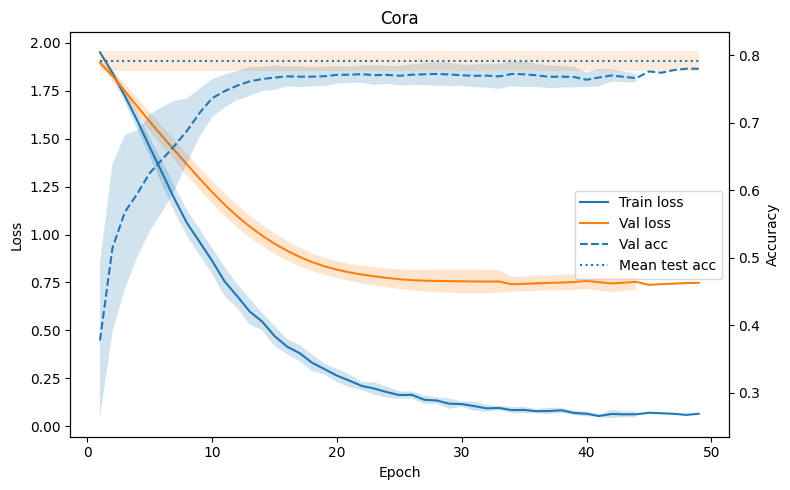

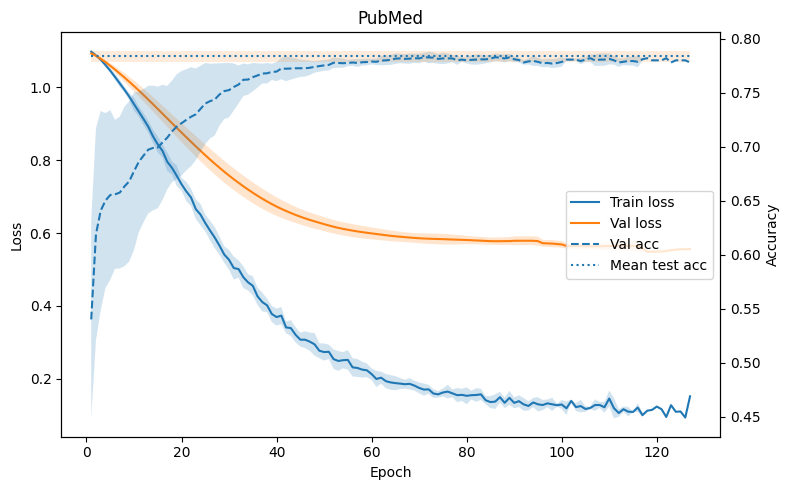

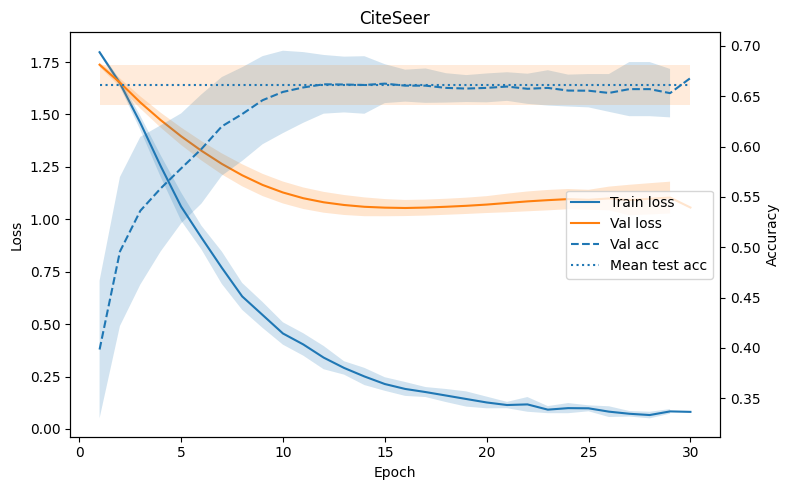

In [5]:
# plotting

plot_dataset_results("../results/gcn_results_Cora.json", "Cora")
plot_dataset_results("../results/gcn_results_PubMed.json", "PubMed")
plot_dataset_results("../results/gcn_results_CiteSeer.json", "CiteSeer")

Across all three datasets, the GCN converges quickly in the first epochs: training loss decreases steadily, validation loss drops early and then plateaus, and validation accuracy rises rapidly before stabilizing. The gap between training and validation loss becomes more pronounced over time, indicating mild overfitting, but early stopping prevents stronger degradation. Test accuracy remains close to the final validation accuracy on all datasets, suggesting that the selected models generalize reasonably well. Overall, the training dynamics are stable and consistent across Cora, PubMed, and CiteSeer, with PubMed achieving the strongest performance and CiteSeer appearing the most challenging.

Dataset Cora already available, no download necessary.
------------- DATA SET INFOS ------------- 
Number of nodes: 2708
Number of edges: 10556
Number of features per Node: 1433
Number of targets in this dataset: 7
Epoch: 1 | Train Loss: 1.9485 | Val Loss: 1.8686 | Val Acc: 0.6080 | Train Time: 0.1441s
Epoch: 2 | Train Loss: 1.8311 | Val Loss: 1.7770 | Val Acc: 0.7300 | Train Time: 0.0030s
Epoch: 3 | Train Loss: 1.7027 | Val Loss: 1.6724 | Val Acc: 0.7500 | Train Time: 0.0012s
Epoch: 4 | Train Loss: 1.5519 | Val Loss: 1.5733 | Val Acc: 0.7640 | Train Time: 0.0012s
Epoch: 5 | Train Loss: 1.4168 | Val Loss: 1.4819 | Val Acc: 0.7700 | Train Time: 0.0012s
Epoch: 6 | Train Loss: 1.2716 | Val Loss: 1.4017 | Val Acc: 0.7680 | Train Time: 0.0012s
Epoch: 7 | Train Loss: 1.1455 | Val Loss: 1.3277 | Val Acc: 0.7660 | Train Time: 0.0011s
Epoch: 8 | Train Loss: 1.0115 | Val Loss: 1.2555 | Val Acc: 0.7640 | Train Time: 0.0011s
Epoch: 9 | Train Loss: 0.9107 | Val Loss: 1.1857 | Val Acc: 0.7760 | Trai

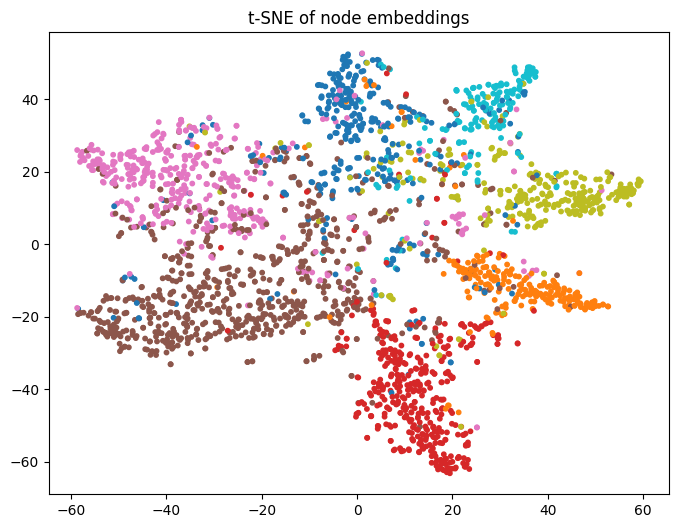

In [ ]:
# t-SNE visualization of node embeddings of final layer
def run_single_for_viz(cfg):
    seeds = [int(s) for s in cfg["seeds"]]
    set_seed(seeds[0])

    if "__file__" in globals():
        project_root = Path(__file__).resolve().parents[1]
    else:
        project_root = Path("..").resolve()

    device = torch.device(cfg["train"]["device"] if torch.cuda.is_available() else "cpu")

    data = load_data(
        cfg["data"]["data_name"],
        str(project_root / "data"),
        cfg["data"]["data_class"]
    )
    data_x = data.x.to(device)
    data_y = data.y.to(device)

    lr = float(cfg["train"]["lr"])
    epochs = int(cfg["train"]["epochs"])
    weight_decay = float(cfg["train"]["weight_decay"])
    hidden_dim = int(cfg["model"]["hidden_dim"])
    dropout = float(cfg["model"]["dropout"])
    early_stopping = int(cfg["model"]["early_stopping"])
    num_neighbors = cfg["data"]["num_neighbors"]
    batch_mode = cfg["data"]["batch_mode"]
    batch_size = int(cfg["data"]["batch_size"])

    input_dim = data.num_features
    output_dim = data.y.unique().size(0)

    train_cfg = TrainConfig(
        epochs=epochs,
        early_stop=early_stopping,
        batch_mode=batch_mode,
        batch_size=batch_size,
        num_neighbors=num_neighbors,
        device=device
    )

    graph_data = GraphDataBundle(
        x=data_x,
        y=data_y,
        A_hat=None,
        train_mask=data.train_mask,
        val_mask=data.val_mask,
        test_mask=data.test_mask,
        data=data
    )

    train_loader, val_loader, test_loader = None, None, None
    if batch_mode == "full_batch":
        graph_data.A_hat = compute_A_hat(data).to(device)
        model = GCNFullBatch(input_dim, hidden_dim, output_dim, dropout).to(device)
    else:
        train_loader, val_loader, test_loader = build_neighbor_loaders(graph_data, train_cfg)
        model = GCNMiniBatch(input_dim, hidden_dim, output_dim, dropout).to(device)

    optimizer = optim.Adam(
        [
            {"params": model.layer1.parameters(), "weight_decay": weight_decay},
            {"params": model.layer2.parameters(), "weight_decay": 0.0},
        ],
        lr=lr
    )
    loss_function = nn.CrossEntropyLoss()

    history, summary = train(model, optimizer, loss_function, graph_data, train_cfg, train_loader, val_loader)

    return model, graph_data, history, summary

cfg = load_config("../configs/cora_1_run.yaml")
model, graph_data, history, summary = run_single_for_viz(cfg)

model.eval()
with torch.no_grad():
    h = model.layer1(graph_data.x, graph_data.A_hat)   # full-batch case
    h = model.relu(h)

z = h.cpu().numpy()
y = graph_data.y.cpu().numpy()

z_2d = TSNE(n_components=2, random_state=42).fit_transform(z)

plt.figure(figsize=(8, 6))
plt.scatter(z_2d[:, 0], z_2d[:, 1], c=y, s=10, cmap="tab10")
plt.title("t-SNE of node embeddings")
plt.show()

The t-SNE visualization of the node embeddings of the Cora data set worked excpetionally well. The model clearly differentiates between classes, even visible on this low-D representation. With an average test accuracy of around 80% this is roughly what could be expected.

## 2.) Addition to paper: Mini-batch implementation

As an extension to the original full-batch GCN, a mini-batch version based on neighborhood sampling was implemented. For small graphs such as Cora, PubMed, and CiteSeer, this does not improve runtime in the given setup but worsens it, since the additional overhead from sampling and subgraph construction outweighs the computational savings. The resulting accuracy is nevertheless only slightly below the full-batch baseline.

To examine the regime where mini-batch training becomes useful, additionally much larger datasets such as ogbn-arxiv (roughly 170k nodes) and (tbd) ogbn-products (roughly 2.7 million nodes) were considered. On graphs of this scale, full-batch training is expected to become increasingly inefficient or infeasible due to GPU memory limits. Therefore, both, accuracy and runtime is compared across graph sizes.

### 2.1) Baseline: mini and full batch on Cora data set

First we run the mini-batch as well as the full-batch approach on the Cora dataset. In both cases the same architecture was used: 

DATA
-  data_name: Cora
-  data_class: Planetoid
-  batch_size: 256
-  batch_mode: full_batch/mini_batch
-  num_neighbors: [10, 10]

MODEL
-  name: gcn
-  hidden_dim: 16
-  dropout: 0.5
-  early_stopping: 10

TRAIN
-  epochs: 200
-  lr: 0.01
-  weight_decay: 0.0005
-  device: cuda

In [18]:
# mini-batch run of Cora
summaries_cmb = []
cfg = load_config("../configs/cora_mini_batch.yaml")
results_cmb = run_from_cfg(cfg)
dataset_name = cfg["data"]["data_name"]
summaries_cmb.append(summarize_results(results_cmb, dataset_name))

Dataset Cora already available, no download necessary.
device: cuda
HYPERPARAMS lr: 0.01 epochs: 200 weight-decay: 0.0005
MODEL ARCHITECTURE: input_dim: 1433 hidden_dim: 16 output_dim: 7 dropout: 0.5
Epoch: 1 | Train Loss: 1.9558 | Val Loss: 1.8925 | Val Acc: 0.2720 | Train Time: 0.0040s
Epoch: 2 | Train Loss: 1.8254 | Val Loss: 1.8021 | Val Acc: 0.4480 | Train Time: 0.0023s
Epoch: 3 | Train Loss: 1.6638 | Val Loss: 1.6868 | Val Acc: 0.6000 | Train Time: 0.0023s
Epoch: 4 | Train Loss: 1.5237 | Val Loss: 1.5649 | Val Acc: 0.6640 | Train Time: 0.0022s
Epoch: 5 | Train Loss: 1.2871 | Val Loss: 1.4462 | Val Acc: 0.7060 | Train Time: 0.0021s
Epoch: 6 | Train Loss: 1.1505 | Val Loss: 1.3282 | Val Acc: 0.7520 | Train Time: 0.0022s
Epoch: 7 | Train Loss: 1.0399 | Val Loss: 1.2257 | Val Acc: 0.7680 | Train Time: 0.0021s
Epoch: 8 | Train Loss: 0.8943 | Val Loss: 1.1494 | Val Acc: 0.7760 | Train Time: 0.0022s
Epoch: 9 | Train Loss: 0.7883 | Val Loss: 1.0701 | Val Acc: 0.8020 | Train Time: 0.0022s

In [ ]:
# full-batch run of Cora
summaries_cfb = []
cfg = load_config("../configs/default_config.yaml")
results_cfb = run_from_cfg(cfg)
dataset_name = cfg["data"]["data_name"]
summaries_cfb.append(summarize_results(results_cfb, dataset_name))

Dataset Cora already available, no download necessary.
device: cuda
HYPERPARAMS lr: 0.01 epochs: 200 weight-decay: 0.0005
MODEL ARCHITECTURE: input_dim: 1433 hidden_dim: 16 output_dim: 7 dropout: 0.5
------------- DATA SET INFOS ------------- 
Number of nodes: 2708
Number of edges: 10556
Number of features per Node: 1433
Number of targets in this dataset: 7
Epoch: 1 | Train Loss: 1.9485 | Val Loss: 1.8686 | Val Acc: 0.6080 | Train Time: 0.0027s
Epoch: 2 | Train Loss: 1.8311 | Val Loss: 1.7770 | Val Acc: 0.7300 | Train Time: 0.0013s
Epoch: 3 | Train Loss: 1.7027 | Val Loss: 1.6724 | Val Acc: 0.7500 | Train Time: 0.0012s
Epoch: 4 | Train Loss: 1.5519 | Val Loss: 1.5733 | Val Acc: 0.7640 | Train Time: 0.0011s
Epoch: 5 | Train Loss: 1.4168 | Val Loss: 1.4819 | Val Acc: 0.7700 | Train Time: 0.0011s
Epoch: 6 | Train Loss: 1.2716 | Val Loss: 1.4017 | Val Acc: 0.7680 | Train Time: 0.0010s
Epoch: 7 | Train Loss: 1.1455 | Val Loss: 1.3277 | Val Acc: 0.7660 | Train Time: 0.0010s
Epoch: 8 | Train 

Results: 
- mini-batch: mean epoch train time of 0.0061s & test set accuracy of 0.7931 (std 0.0062) over 9 runs
- full-batch: mean epoch train time of 0.0014s & test set accuracy of 0.7918 (std 0.0149) over 9 runs

Thus, even though the data sets are extremely small, the full-batch approach has a strong advantage, possbily due to the additional overhead created by the mini-batch approach.

### 2.2) Stresstest 1: obgn-arxiv data set (170k nodes)

To let the model adapt to the increased complexibility the architecture was changed as follows. Hereby no specific hyperparameters estimation techinques or tools were used but manually estimated as the focus lies on the comparison of computing performance and not the final test accuracy.

DATA
-  data_name: ogbn-arxiv
-  data_class: ogbn
-  batch_size: 512
-  batch_mode: full_batch/mini_batch
-  num_neighbors: [15, 15]

MODEL
-  name: gcn
-  hidden_dim: 64
-  dropout: 0.5
-  early_stopping: 10

TRAIN
-  epochs: 200
-  lr: 0.01
-  weight_decay: 0.0005
-  device: cuda

In [4]:
# mini batch run of ogbn-arxiv
summaries_mb_1 = []
cfg = load_config("../configs/ogbn_arxiv_mini_batch.yaml")
results_mb_1 = run_from_cfg(cfg)
dataset_name = cfg["data"]["data_name"]
summaries_mb_1.append(summarize_results(results_mb_1, dataset_name))
# display runtimes

Dataset ogbn-arxiv already available, no download necessary.
device: cuda
HYPERPARAMS lr: 0.01 epochs: 200 weight-decay: 0.0005
MODEL ARCHITECTURE: input_dim: 128 hidden_dim: 64 output_dim: 40 dropout: 0.5
Epoch: 1 | Train Loss: 1.9756 | Val Loss: 1.5737 | Val Acc: 0.5521 | Train Time: 0.6894s
Epoch: 2 | Train Loss: 1.6591 | Val Loss: 1.5318 | Val Acc: 0.5589 | Train Time: 0.6676s
Epoch: 3 | Train Loss: 1.6148 | Val Loss: 1.4758 | Val Acc: 0.5687 | Train Time: 0.6764s
Epoch: 4 | Train Loss: 1.5898 | Val Loss: 1.4589 | Val Acc: 0.5744 | Train Time: 0.6745s
Epoch: 5 | Train Loss: 1.5838 | Val Loss: 1.4829 | Val Acc: 0.5623 | Train Time: 0.6712s
Epoch: 6 | Train Loss: 1.5749 | Val Loss: 1.4658 | Val Acc: 0.5743 | Train Time: 0.6711s
Epoch: 7 | Train Loss: 1.5686 | Val Loss: 1.4549 | Val Acc: 0.5768 | Train Time: 0.6702s
Epoch: 8 | Train Loss: 1.5679 | Val Loss: 1.4381 | Val Acc: 0.5842 | Train Time: 0.6724s
Epoch: 9 | Train Loss: 1.5530 | Val Loss: 1.4265 | Val Acc: 0.5804 | Train Time: 0

In [5]:
# full batch run of ogbn-arxiv
summaries_fb = []
cfg = load_config("../configs/ogbn_arxiv_full_batch.yaml")
results_fb = run_from_cfg(cfg)
dataset_name = cfg["data"]["data_name"]
summaries_fb.append(summarize_results(results_fb, dataset_name))

Dataset ogbn-arxiv already available, no download necessary.
device: cuda
HYPERPARAMS lr: 0.01 epochs: 200 weight-decay: 0.0005
MODEL ARCHITECTURE: input_dim: 128 hidden_dim: 64 output_dim: 40 dropout: 0.5
------------- DATA SET INFOS ------------- 
Number of nodes: 169343
Number of edges: 1166243
Number of features per Node: 128
Number of targets in this dataset: 40
Epoch: 1 | Train Loss: 3.7769 | Val Loss: 3.4724 | Val Acc: 0.0293 | Train Time: 0.0526s
Epoch: 2 | Train Loss: 3.5341 | Val Loss: 3.2987 | Val Acc: 0.2818 | Train Time: 0.0201s
Epoch: 3 | Train Loss: 3.3426 | Val Loss: 3.1331 | Val Acc: 0.2799 | Train Time: 0.0240s
Epoch: 4 | Train Loss: 3.1914 | Val Loss: 3.0087 | Val Acc: 0.2785 | Train Time: 0.0202s
Epoch: 5 | Train Loss: 3.1059 | Val Loss: 2.9478 | Val Acc: 0.2691 | Train Time: 0.0199s
Epoch: 6 | Train Loss: 3.0753 | Val Loss: 2.9044 | Val Acc: 0.2732 | Train Time: 0.0198s
Epoch: 7 | Train Loss: 3.0492 | Val Loss: 2.8424 | Val Acc: 0.2868 | Train Time: 0.0202s
Epoch: 

/local/data/ipv577/projects_new/.project_venv/lib/python3.12/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


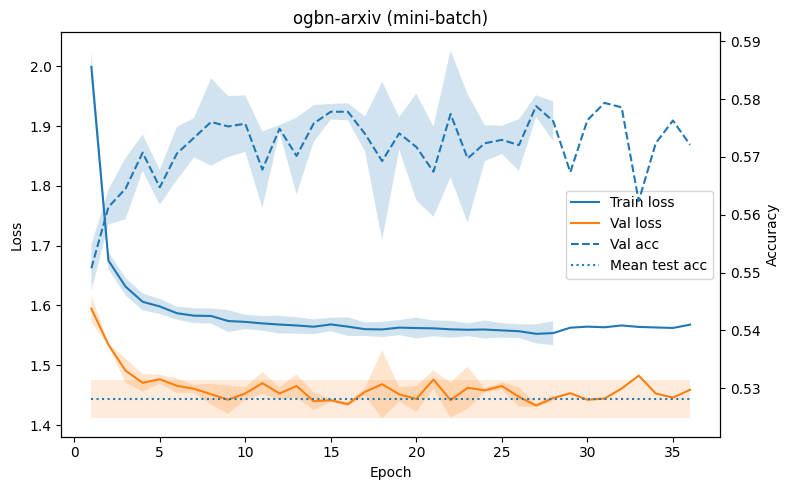

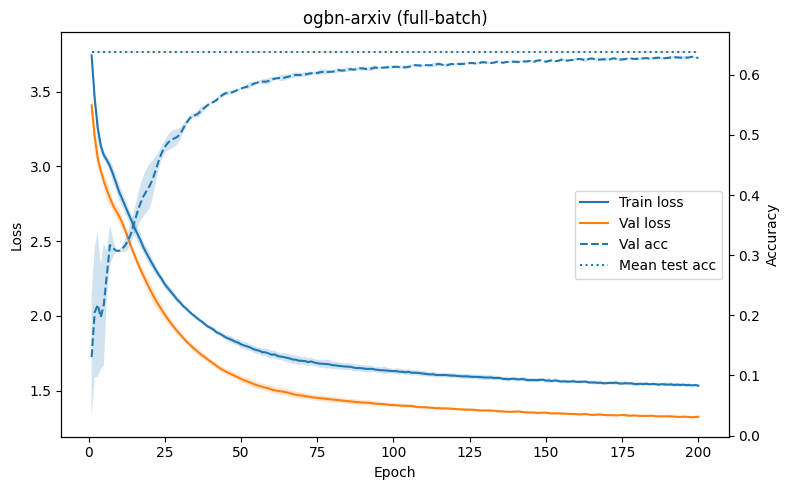

In [8]:
plot_dataset_results("../results/gcn_results_ogbn-arxiv_mb.json", "ogbn-arxiv (mini-batch)")
plot_dataset_results("../results/gcn_results_ogbn-arxiv_fb.json", "ogbn-arxiv (full-batch)")

On ogbn-arxiv, full-batch clearly remains superior in this setup. It achieves a mean test accuracy of 0.6385, compared to 0.5281 for the mini-batch variant, while also being much faster per epoch (0.024s vs. 0.827s). This is consistent with the training curves above: full-batch converges more smoothly and to a better optimum, whereas mini-batch shows noisier validation behavior and lower final performance. In other words, this graph is still not large enough for mini-batch training to become advantageous on our hardware. With 24 GB of GPU memory, full-batch training on ogbn-arxiv is still easily feasible and even substantially more efficient. The next natural step is therefore to move to a much larger graph, where full-batch training is expected to approach its memory and runtime limits and the practical benefit of mini-batch training should become more apparent.


### 2.3) Stresstest 2: obgn-products data set (2.7 million nodes)

In [ ]:
# tbd